<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%205/W05_L4_Visualizing_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=tmpzLPmMBD0) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%205/NPTEL_Jul24_DL4CV_W05_P04.pdf)

In [ ]:
# Week 5, Lecture 4: Visualizing CNN
from IPython.display import HTML, display

VIDEO_ID = "tmpzLPmMBD0"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 5, Lecture 4: Visualizing CNNs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§5.4 Visualizing CNNs**.

A trained CNN is not a black box we have to accept on faith. This lecture builds six practical
tools for looking inside a pretrained **ResNet-18** and asking *what has it learned* and *what is
it looking at*.

**What you will learn**
- Visualize the **first-layer filters** and see the Gabor-like edge and color detectors they learn.
- Visualize **intermediate activations** (feature maps) using forward hooks.
- Find the **maximally activating images** for a chosen neuron.
- Run an **occlusion experiment** to build a class-saliency heatmap (Zeiler and Fergus, 2014).
- Compute a fast **gradient saliency** map with a single backward pass.
- Visualize the **penultimate representation space** with PCA and t-SNE.

**Contents**

1. Load the model and a sample image
2. Method 1: First-layer filters
3. Method 2: Visualize activations (feature maps)
4. Method 3: Maximally activating images
5. Method 4: Occlusion experiment (Zeiler and Fergus, 2014)
6. Method 5: Gradient saliency (a fast complement to occlusion)
7. Method 6: Representation space (last layer)

**How to run**
- **Self-contained.** Every setup step runs inside the notebook; the only downloads are the
  pretrained ResNet-18 weights and a small CIFAR-10 subset.
- **Runs on CPU or GPU**, locally or on Google Colab. All cells are tuned to finish in a few seconds.
- **Interactive.** Several cells end in a widget: run the cell, then drag the slider or pick from the
  dropdown and watch the figure update.
- Read the short **"What to notice"** prompt near each widget so you know what to look for.

## Setup

In [1]:
# Setup: runs on CPU or GPU, on Colab or locally.
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets is preinstalled on Colab; install only if missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, interactive

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def count_params(module):
    # Total number of parameters in a module.
    return sum(p.numel() for p in module.parameters())

def count_trainable(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

Using device: cpu


## 1. Load the model and a sample image

We use a **pretrained ResNet-18** from torchvision (trained on ImageNet, 1000 classes). We read the
human-readable class names straight from the weights metadata, so no label file needs downloading.

Our test image is `grace_hopper.jpg`, which ships with matplotlib. Before probing the network we
confirm it actually works by printing its **top-5 predictions**.

Model params: 11,689,512
Number of classes: 1000

Top-5 predictions for the sample image:
  0.670  military uniform
  0.043  bow tie
  0.030  bearskin
  0.024  bulletproof vest
  0.023  academic gown


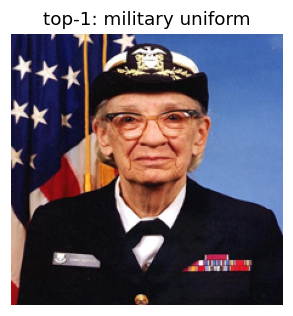

In [2]:
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
import matplotlib.cbook as cbook
from PIL import Image

weights = ResNet18_Weights.DEFAULT
categories = weights.meta['categories']          # 1000 ImageNet class names, no download
model = resnet18(weights=weights).eval().to(device)
print('Model params:', f'{count_params(model):,}')
print('Number of classes:', len(categories))

# ImageNet preprocessing (matches how the model was trained).
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def load_sample_image(size=224):
    with cbook.get_sample_data('grace_hopper.jpg') as f:
        img = Image.open(f).convert('RGB').resize((size, size))
    return img

def denorm(x):
    # Undo ImageNet normalization for display; x is [3,H,W] or [B,3,H,W].
    x = x.detach().cpu()
    if x.dim() == 3:
        x = x.unsqueeze(0)
    x = (x * std + mean).clamp(0, 1)
    return x

sample_img = load_sample_image(224)
x_sample = preprocess(sample_img).unsqueeze(0).to(device)   # [1,3,224,224]

with torch.no_grad():
    probs = model(x_sample).softmax(dim=1)[0]
top5 = probs.topk(5)
print('\nTop-5 predictions for the sample image:')
for p, idx in zip(top5.values, top5.indices):
    print(f'  {p.item():5.3f}  {categories[idx]}')

fig, ax = plt.subplots(figsize=(3.2, 3.2))
ax.imshow(sample_img); ax.set_title(f'top-1: {categories[top5.indices[0]]}'); ax.axis('off')
plt.show()

## 2. Method 1: First-layer filters

**Why.** The first convolution acts **directly on RGB pixels**, so its weights are directly
interpretable as small image patches. Deeper kernels act on **feature maps**, not pixels, so their
raw weights are not visually meaningful.

**What to expect.** The 64 filters of ResNet-18's `conv1` (shape `64 x 3 x 7 x 7`) typically look
like **Gabor-like oriented edge detectors** and **color blobs**, the same primitives found in early
visual cortex and in almost every CNN regardless of architecture.

Each filter is normalized to `[0, 1]` independently before display.

conv1 weight shape: (64, 3, 7, 7)


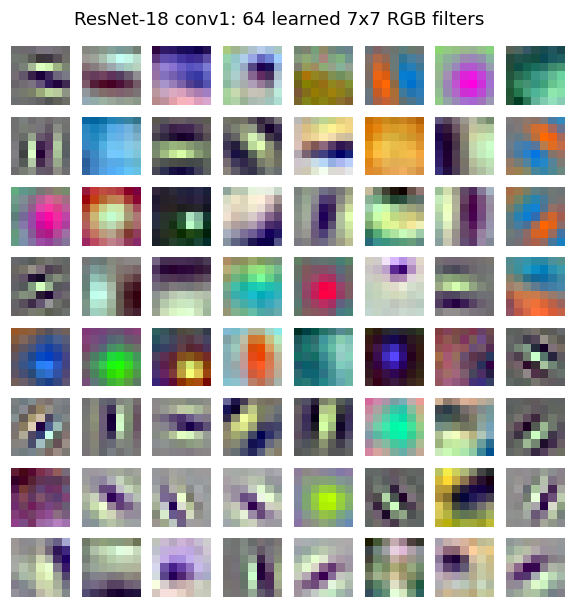

In [3]:
W = model.conv1.weight.data.clone().cpu()      # [64, 3, 7, 7]
print('conv1 weight shape:', tuple(W.shape))

# Normalize every filter independently to [0,1] so its color pattern is visible.
Wn = torch.empty_like(W)
for i in range(W.shape[0]):
    f = W[i]
    Wn[i] = (f - f.min()) / (f.max() - f.min() + 1e-8)

fig, axes = plt.subplots(8, 8, figsize=(6.5, 6.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(Wn[i].permute(1, 2, 0).numpy())
    ax.axis('off')
fig.suptitle('ResNet-18 conv1: 64 learned 7x7 RGB filters', y=0.93)
plt.show()

## 3. Method 2: Visualize activations (feature maps)

**Why.** A filter's weights are static. Its **activation** (feature map) is what it actually outputs
for a specific input. Feature maps show us where in the image each detector fires.

**How.** We attach **forward hooks** to named blocks `layer1..layer4`. A hook is a callback that
grabs a layer's output during the forward pass without changing the model. We run the sample image
once and cache every activation.

**What to notice.** Early layers (`layer1`) respond to **edges and textures** and stay dense; deeper
layers (`layer4`) are **more abstract and sparse**, with fewer active locations. Spatial resolution
shrinks with depth (56, 28, 14, 7).

In [4]:
activations = {}
def make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

layer_names = ['layer1', 'layer2', 'layer3', 'layer4']
handles = [getattr(model, n).register_forward_hook(make_hook(n)) for n in layer_names]

with torch.no_grad():
    _ = model(x_sample)

for h in handles:      # remove hooks; activations dict is now populated
    h.remove()

for n in layer_names:
    print(f'{n:8s} activation shape: {tuple(activations[n].shape)}')

layer1   activation shape: (1, 64, 56, 56)
layer2   activation shape: (1, 128, 28, 28)
layer3   activation shape: (1, 256, 14, 14)
layer4   activation shape: (1, 512, 7, 7)


In [5]:
# WIDGET 1: pick a layer and a channel, see that single feature map.
def show_feature_map(layer='layer1', channel=0):
    act = activations[layer][0]                     # [C, H, W]
    c = min(channel, act.shape[0] - 1)
    fmap = act[c].numpy()
    fig, ax = plt.subplots(1, 2, figsize=(6.4, 3.2))
    ax[0].imshow(sample_img); ax[0].set_title('input'); ax[0].axis('off')
    im = ax[1].imshow(fmap, cmap='viridis')
    ax[1].set_title(f'{layer}  channel {c}/{act.shape[0]-1}  ({act.shape[1]}x{act.shape[2]})')
    ax[1].axis('off'); fig.colorbar(im, ax=ax[1], fraction=0.046)
    plt.show()

interact(show_feature_map,
         layer=widgets.Dropdown(options=layer_names, value='layer1', description='layer'),
         channel=widgets.IntSlider(min=0, max=511, step=1, value=0, description='channel'));

interactive(children=(Dropdown(description='layer', options=('layer1', 'layer2', 'layer3', 'layer4'), value='l…

**Try this:** switch `layer` from `layer1` to `layer4` at a fixed channel. Notice the map gets
smaller and blockier and lights up in fewer places. Below is a static grid of the first 16 channels
of `layer1` so you can compare detectors at a glance (many respond to oriented edges).

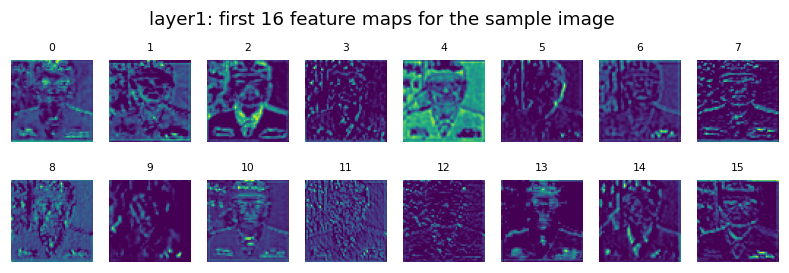

In [6]:
act1 = activations['layer1'][0]         # [64, 56, 56]
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for i, ax in enumerate(axes.flat):
    ax.imshow(act1[i].numpy(), cmap='viridis'); ax.axis('off'); ax.set_title(str(i), fontsize=7)
fig.suptitle('layer1: first 16 feature maps for the sample image', y=1.02)
plt.show()

### A small image pool for the next experiments

Methods 3 and 6 need many images. We load a **CIFAR-10 subset** (300 images), upsize to 96x96,
and run one forward pass while two hooks capture:
- the `layer2` output (128 channels) for the maximally-activating-image search, and
- the penultimate `avgpool` vector (512-dim) for the representation-space plot.

We compute this once and cache it so the widgets stay fast.

In [7]:
from torchvision import datasets
from torch.utils.data import Subset

cifar_classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
tf_disp = transforms.Compose([transforms.Resize(96), transforms.ToTensor()])   # 0..1, for display
pool_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=tf_disp)
N_POOL = 300
pool = Subset(pool_ds, range(N_POOL))

Xdisp = torch.stack([pool[i][0] for i in range(N_POOL)])          # [N,3,96,96] in 0..1
y_pool = torch.tensor([pool[i][1] for i in range(N_POOL)])
Xnorm = (Xdisp - mean) / std                                      # ImageNet-normalized

# Two hooks: layer2 mean activation per channel, and the 512-dim penultimate vector.
buf = {}
h2 = model.layer2.register_forward_hook(lambda m, i, o: buf.__setitem__('l2', o.detach().cpu()))
hp = model.avgpool.register_forward_hook(lambda m, i, o: buf.__setitem__('ap', o.detach().cpu()))

l2_means, feats = [], []
with torch.no_grad():
    for s in range(0, N_POOL, 50):
        _ = model(Xnorm[s:s+50].to(device))
        l2_means.append(buf['l2'].mean(dim=(2, 3)))               # [b,128]
        feats.append(buf['ap'].flatten(1))                        # [b,512]
h2.remove(); hp.remove()

l2_means = torch.cat(l2_means).numpy()      # [N,128]  mean activation per channel per image
feats = torch.cat(feats).numpy()            # [N,512]  penultimate features
print('layer2 mean-activation matrix:', l2_means.shape)
print('penultimate feature matrix:   ', feats.shape)

layer2 mean-activation matrix: (300, 128)
penultimate feature matrix:    (300, 512)


## 4. Method 3: Maximally activating images

**Why.** To learn what a hidden neuron detects, find the images from a pool that make it **fire the
hardest**. The common content across those images is (roughly) the pattern that neuron encodes, and
the receptive-field patch that drives it is the concrete feature.

**How.** For a chosen `layer2` channel we already stored its **mean activation per image**. We simply
sort the pool by that score and show the **top-k** images.

In [8]:
# WIDGET 2: pick a layer2 channel, see the images from the pool that activate it most.
def top_activating(channel=0, k=8):
    scores = l2_means[:, channel]
    order = np.argsort(-scores)[:k]
    fig, axes = plt.subplots(1, k, figsize=(1.5 * k, 1.8))
    for ax, idx in zip(axes, order):
        ax.imshow(Xdisp[idx].permute(1, 2, 0).numpy())
        ax.set_title(f'{cifar_classes[y_pool[idx]]}\n{scores[idx]:.2f}', fontsize=8)
        ax.axis('off')
    fig.suptitle(f'layer2 channel {channel}: top-{k} activating images (of {N_POOL})', y=1.15)
    plt.show()

interact(top_activating,
         channel=widgets.IntSlider(min=0, max=127, step=1, value=10, description='channel'),
         k=widgets.IntSlider(min=4, max=10, step=1, value=8, description='top-k'));

interactive(children=(IntSlider(value=10, description='channel', max=127), IntSlider(value=8, description='top…

**What to notice:** as you scan channels, some neurons prefer a **dominant color** (blue sky or
water), others prefer a **shape or texture** (round animal bodies, straight vehicle edges). The top
images for one channel tend to share a visual theme, which is the neuron's specialty.

## 5. Method 4: Occlusion experiment (Zeiler and Fergus, 2014)

**Why.** Does the model use the object, or some background shortcut? Slide a small **gray patch** over
the image; wherever hiding a region causes the **biggest drop** in the predicted-class probability is
the region the model relies on. Plotting that probability over all patch positions gives a
**saliency heatmap**.

**How (efficiently).** Naively this is one forward pass per patch position. Instead we **stack every
occluded variant into a single batch** and run one forward pass. We use a modest 112x112 image and a
coarse stride so it finishes in a moment.

In [9]:
img112 = load_sample_image(112)
# ToTensor then Normalize at 112x112 (reuse the last two preprocessing transforms).
x112 = preprocess.transforms[-1](preprocess.transforms[-2](img112)).unsqueeze(0).to(device)
with torch.no_grad():
    base_probs = model(x112).softmax(1)[0]
target = int(base_probs.argmax())
print(f'target class at 112x112: {categories[target]}  (p={base_probs[target]:.3f})')

def occlusion_heatmap(x, target, occ=24, stride=12):
    # Return an (rows x cols) grid of predicted-class prob with a gray patch at each position.
    _, C, H, Wd = x.shape
    tops = list(range(0, H, stride))
    lefts = list(range(0, Wd, stride))
    batch = []
    for t in tops:
        for l in lefts:
            v = x.clone()
            v[:, :, t:t+occ, l:l+occ] = 0.0        # 0 in normalized space is a neutral gray
            batch.append(v)
    batch = torch.cat(batch, 0)                    # [rows*cols, C, H, W], one big batch
    with torch.no_grad():
        p = model(batch).softmax(1)[:, target].cpu().numpy()
    return p.reshape(len(tops), len(lefts))

# WIDGET 3: occluder size and stride control the heatmap (coarser stride = fewer forward inputs).
def occlusion_demo(occ=24, stride=14):
    t0 = time.time()
    heat = occlusion_heatmap(x112, target, occ=occ, stride=stride)
    dt = time.time() - t0
    disp = denorm(x112)[0].permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(1, 3, figsize=(9.5, 3.3))
    ax[0].imshow(disp); ax[0].set_title('image'); ax[0].axis('off')
    im = ax[1].imshow(heat, cmap='jet_r')          # dark red = big prob drop = important region
    ax[1].set_title(f'P({categories[target].split(",")[0]}) heatmap')
    ax[1].axis('off'); fig.colorbar(im, ax=ax[1], fraction=0.046)
    ax[2].imshow(disp)
    ax[2].imshow(heat, cmap='jet_r', alpha=0.55, extent=[0, 112, 112, 0], interpolation='bilinear')
    ax[2].set_title('overlay'); ax[2].axis('off')
    fig.suptitle(f'{heat.size} occluded variants in one batch, {dt:.2f}s', y=1.02)
    plt.show()

interact(occlusion_demo,
         occ=widgets.IntSlider(min=12, max=48, step=4, value=24, description='occluder'),
         stride=widgets.IntSlider(min=8, max=28, step=2, value=14, description='stride'));

target class at 112x112: bow tie  (p=0.989)


interactive(children=(IntSlider(value=24, description='occluder', max=48, min=12, step=4), IntSlider(value=14,…

**Try this:** shrink the `stride` for a finer, slower map and enlarge it for a coarse, fast map.
The **darkest region** (largest probability drop) marks the pixels the model most depends on for this
class. For grace_hopper the map concentrates on the uniform and face, not the background.

## 6. Method 5: Gradient saliency (a fast complement to occlusion)

**Why.** Occlusion needs many forward passes. **Gradient saliency** answers a related question with a
**single backward pass**: which input pixels, if nudged, would most change the class score?

**How.** Set `requires_grad` on the input, do one forward pass, backprop the top class score to the
pixels, and take the **max absolute gradient across the three color channels**:
$$S(i,j) = \max_{c \in \{R,G,B\}} \left| \frac{\partial \, y_{\text{class}}}{\partial \, x_{c,i,j}} \right|.$$

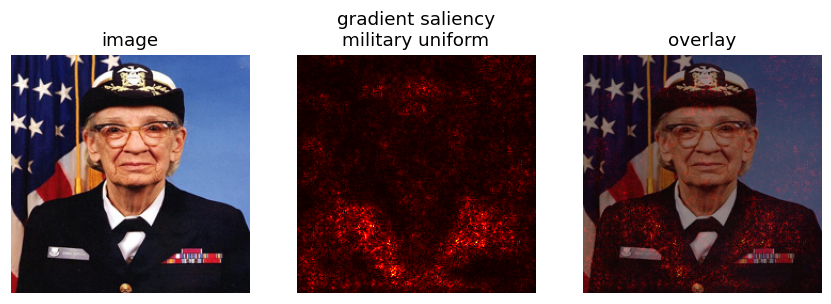

Bright pixels are the ones the class score is most sensitive to.


In [10]:
x_g = x_sample.clone().requires_grad_(True)
score = model(x_g)                                  # [1,1000]
cls = int(score.argmax())
model.zero_grad()
score[0, cls].backward()                            # one backward pass
sal = x_g.grad.detach().abs().amax(dim=1)[0].cpu().numpy()   # max over color channels -> [224,224]
sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)

fig, ax = plt.subplots(1, 3, figsize=(9.5, 3.3))
ax[0].imshow(sample_img); ax[0].set_title('image'); ax[0].axis('off')
ax[1].imshow(sal, cmap='hot'); ax[1].set_title(f'gradient saliency\n{categories[cls].split(",")[0]}')
ax[1].axis('off')
ax[2].imshow(sample_img); ax[2].imshow(sal, cmap='hot', alpha=0.5); ax[2].set_title('overlay')
ax[2].axis('off')
plt.show()
print('Bright pixels are the ones the class score is most sensitive to.')

## 7. Method 6: Representation space (last layer)

**Why.** The **penultimate 512-dim vector** (just before the classifier) is the CNN's compact code for
an image. Two images with nearby codes are ones the network sees as **semantically similar**, not
merely similar in raw pixels or color. Visualizing this space shows whether the model has organized
images into meaningful clusters.

**How.** Project the 512-dim features of the pool to 2D two ways:
- **PCA**: linear, fast, keeps the directions of largest variance.
- **t-SNE**: nonlinear, slower, preserves local neighborhoods and tends to reveal tight clusters.

We color each point by its true CIFAR class.

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca_2d = PCA(n_components=2).fit_transform(feats)     # [N,2]
_tsne_cache = {}
def tsne_2d(perplexity):
    if perplexity not in _tsne_cache:
        _tsne_cache[perplexity] = TSNE(n_components=2, perplexity=perplexity,
                                       init='pca', learning_rate='auto',
                                       random_state=0).fit_transform(feats)
    return _tsne_cache[perplexity]

cmap10 = plt.get_cmap('tab10')
def scatter2d(ax, XY, title):
    yn = y_pool.numpy()
    for c in range(10):
        m = (yn == c)
        ax.scatter(XY[m, 0], XY[m, 1], s=14, color=cmap10(c), label=cifar_classes[c])
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

# WIDGET 4: switch between PCA and t-SNE (perplexity only affects t-SNE).
def repr_demo(method='PCA', perplexity=30):
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    if method == 'PCA':
        scatter2d(ax, pca_2d, 'PCA of 512-dim penultimate features')
    else:
        scatter2d(ax, tsne_2d(perplexity), f't-SNE (perplexity={perplexity})')
    ax.legend(markerscale=1.4, fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.show()

interact(repr_demo,
         method=widgets.Dropdown(options=['PCA', 't-SNE'], value='PCA', description='method'),
         perplexity=widgets.IntSlider(min=5, max=50, step=5, value=30, description='perplexity'));

/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encounter

interactive(children=(Dropdown(description='method', options=('PCA', 't-SNE'), value='PCA'), IntSlider(value=3…

**What to notice:** even though the model was never trained on CIFAR, its ImageNet features
already **separate the classes** into groups (vehicles apart from animals, and so on). t-SNE usually
shows **tighter, rounder clusters** than PCA; try a few perplexity values and watch the clusters
tighten or merge.

## Key takeaways: two families of methods

| Family | Methods | Idea |
|---|---|---|
| **Do not disturb the model** | first-layer filters, activations, maximally activating images, representation space | read out what the fixed network already stores |
| **Perturb the input** | occlusion, gradient saliency | change the input and watch the output move |

- **Filters** show the primitive detectors learned in the first layer.
- **Activations** show where those detectors fire for a specific image.
- **Maximally activating images** reveal a neuron's preferred pattern from data.
- **Representation space** shows the global semantic geometry the model has built.
- **Occlusion** and **gradient saliency** both localize the pixels responsible for a prediction,
  one by covering regions (many forward passes) and one by differentiation (a single backward pass).

## Key takeaways
- **First-layer filters are interpretable; deeper kernels are not** (they act on feature maps, not pixels).
- **Forward hooks** are the standard, non-invasive way to read any internal activation.
- **Maximally activating images** turn an abstract neuron into a concrete visual concept.
- **Occlusion** and **gradient saliency** are complementary: occlusion is model-agnostic but costly,
  gradients are cheap but noisier.
- The **penultimate features** encode semantic similarity; PCA and t-SNE make that geometry visible.
- Batching perturbations (as in the occlusion cell) is what keeps these experiments fast on a CPU.

## Further reading
- Zeiler and Fergus, *Visualizing and Understanding Convolutional Networks*, ECCV 2014 (occlusion and deconvnet).
- van der Maaten and Hinton, *Visualizing Data using t-SNE*, JMLR 2008.
- Yosinski, Clune, Nguyen, Fuchs, Lipson, *Understanding Neural Networks Through Deep Visualization*, ICML DL Workshop 2014.
- Stanford CS231n, *Visualizing what ConvNets learn* (course notes).